# 05 — DKVMN refit (corrected memory ordering): junyi, seed 20260202

**Why this run exists.** In the archived pipeline `DKVMN.forward` read the value memory
*before* writing interaction *t*, so its prediction for target *t+1* was formed from
interactions 0…*t*−1 while all seven other models used 0…*t*. DKVMN alone was denied the
most recent interaction. That is not the Zhang et al. (2017) formulation.

**Why only DKVMN is retrained.** The other seven models are independent of it, the split
is a deterministic function of dataset and seed, and the fix is parameter-neutral, so the
capacity search lands on the same hidden width. The corrected DKVMN predictions can
therefore be substituted into the archived prediction matrix and every downstream table
recomputed — without retraining anything else, and without producing a second value for
any quantity the archived run already reports.

**Gate.** Cell 4 refuses to continue unless the rebuilt split reproduces the archived
bucket counts exactly. If it does not, the substitution is invalid and the whole run must
be repeated instead.

Reads `RQ2RQ3__junyi__seed0` read-only. Writes only into `runs/DKVMNFIX__junyi__seed0/`.

In [1]:
# --- locate pcdt_p2.py and p2_runtime.py -----------------------------------------
import os, sys, json, time, glob
_here = os.path.abspath("")
for _c in (_here, os.path.dirname(_here), os.path.join(_here, "..")):
    if os.path.exists(os.path.join(_c, "pcdt_p2.py")):
        sys.path.insert(0, os.path.abspath(_c)); break
import numpy as np, pandas as pd, matplotlib
matplotlib.use("Agg") if os.environ.get("P2_HEADLESS") else None
import matplotlib.pyplot as plt
import pcdt_p2 as P
import p2_runtime as R
pd.set_option("display.width", 220)
print("pcdt_p2   :", P.__file__)
print("p2_runtime:", R.__file__)
assert hasattr(P.Config(), "dkvmn_legacy_lag"), (
    "This notebook requires the CORRECTED pcdt_p2.py. The copy on the path is the "
    "archived one, in which DKVMN reads its value memory before writing the current "
    "interaction. Refitting against it would reproduce the defect, not repair it.")


pcdt_p2   : /home/hamed/Downloads/Research/P02/pcdt_p2.py
p2_runtime: /home/hamed/Downloads/Research/P02/p2_runtime.py


In [2]:
# ============================================================================
# CONFIGURATION — GENERATED. Nothing to edit.
# ============================================================================
RUN_ID    = "DKVMNFIX__junyi__seed0"
OUT_ROOT  = "/home/hamed/Downloads/Research/P02/PCDT_P2_runs"
DATASET   = "junyi"
SEED_INDEX = 0
SOURCE_RUN = "RQ2RQ3__junyi__seed0"

CFG = P.Config(dataset=DATASET, out_root=OUT_ROOT, seed_index=SEED_INDEX,
               dkvmn_legacy_lag=False)          # <-- the correction
assert CFG.seed == 20260202, CFG.seed

CTX = R.RunContext(RUN_ID, OUT_ROOT, cfg=CFG,
                   inputs_expected=[SOURCE_RUN + "/predictions_test.npz",
                                    SOURCE_RUN + "/table1_bucket_counts.csv"],
                   description="DKVMN refit with corrected memory ordering — "
                               "junyi, seed 20260202")
DIRS = CTX.dirs
print("dataset :", DATASET, "| seed:", CFG.seed, "| legacy lag:", CFG.dkvmn_legacy_lag)
print("paths   :", CFG.paths)

RUN DKVMNFIX__junyi__seed0
DKVMN refit with corrected memory ordering — junyi, seed 20260202
started   2026-08-18 19:37:41   pid 867145
writes to /home/hamed/Downloads/Research/P02/PCDT_P2_runs/runs/DKVMNFIX__junyi__seed0
reads     RQ2RQ3__junyi__seed0/predictions_test.npz, RQ2RQ3__junyi__seed0/table1_bucket_counts.csv
dataset : junyi | seed: 20260202 | legacy lag: False
paths   : {'log': '/home/hamed/Downloads/Research/dataset/junyi/Log_Problem.csv', 'content': '/home/hamed/Downloads/Research/dataset/junyi/Info_Content.csv'}


In [3]:
DF = P.load_dataset(CFG)
PACKS, N_SKILLS = P.build_packs(DF, CFG, np.random.default_rng(CFG.seed),
                                P.temporal_profile(DF)[2])
TEST_BUCKET = P.bucket_of(PACKS["test"])
Y = PACKS["test"]["correct"][:, 1:]
M = PACKS["test"]["mask"][:, 1:] > 0
BC = P.bucket_counts(PACKS, TEST_BUCKET)
print(f"skill vocabulary (train-derived): {N_SKILLS:,}")
print(BC.to_string(index=False))

[junyi] 16,921 learners | 4,482,120 interactions | 25,232 items | 1,326 skills | correct 0.704 | median span 33.1 d
        behavioural signals present: ['response_time', 'hint_frac', 'attempt_count']
  train 8,460 learners | 894,352 interactions
  val   1,691 learners | 180,588 interactions
  test  6,770 learners | 717,917 interactions
skill vocabulary (train-derived): 1,327
horizon  points  learners
 within  673602      6770
sameday   12752      3772
     d1   15132      4255
     d7    6490      2984
    d28    3171      2124


In [4]:
# ============================================================================
# SPLIT GATE — the substitution is only valid if this split IS the archived split
# ============================================================================
_base = CTX.sibling(SOURCE_RUN)
if _base is None:
    raise FileNotFoundError(f"source run {SOURCE_RUN} not found under {CTX.runs_root}")
_bc = pd.read_csv(CTX.read_input(os.path.join(_base, "tables", "table1_bucket_counts.csv"),
                                 label=SOURCE_RUN + "/table1"))
_mine = BC.set_index("horizon")[["points", "learners"]]
_theirs = _bc.set_index("horizon")[["points", "learners"]]
_cmp = _mine.join(_theirs, lsuffix="_now", rsuffix="_archived")
print(_cmp.to_string())
_bad = [(h, c) for h in _mine.index for c in ("points", "learners")
        if int(_mine.loc[h, c]) != int(_theirs.loc[h, c])]
if _bad:
    raise AssertionError(
        "SPLIT GATE FAILED: the rebuilt split does not reproduce the archived one at "
        f"{_bad}. The corrected DKVMN predictions cannot be substituted into "
        f"{SOURCE_RUN}'s prediction matrix, because they would not be aligned with the "
        "other seven models' rows. Re-run the full 02_RQ2RQ3 notebook instead.")
print("\nSPLIT GATE PASSED — every bucket count reproduces the archived run exactly.")

  read input     RQ2RQ3__junyi__seed0/table1
         points_now  learners_now  points_archived  learners_archived
horizon                                                              
within       673602          6770           673602               6770
sameday       12752          3772            12752               3772
d1            15132          4255            15132               4255
d7             6490          2984             6490               2984
d28            3171          2124             3171               2124

SPLIT GATE PASSED — every bucket count reproduces the archived run exactly.


In [5]:
import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLS = P.build_model_classes()
print("device:", DEVICE)
if DEVICE.type != "cuda":
    print("*** No GPU detected. DKVMN steps through the sequence in Python; this will be "
          "very slow on CPU. ***")

spec = P.model_specs(N_SKILLS, CFG, CLS)["DKVMN"]
hh, npar, ok = P.match_capacity(spec, CFG.param_budget, CFG.param_tolerance)
print(f"capacity-matched hidden={hh} params={npar:,} within tolerance={ok}")

t0 = time.time()
best = (-1e9, None, None)
for lr in CFG.search_lrs:
    mdl, auc = P.train_one(spec, hh, lr, PACKS, CFG, CLS, DEVICE, CFG.seed)
    print(f"  lr={lr:<7g} val AUC={auc:.4f}")
    if auc > best[0]:
        best = (auc, lr, mdl)
print(f"selected lr={best[1]} val AUC={best[0]:.4f}  ({(time.time()-t0)/60:.1f} min)")
DKVMN_NEW = P.predict(best[2], PACKS["test"], CFG, CLS, DEVICE)
torch.save(best[2].state_dict(), os.path.join(DIRS["art"], "model_DKVMN_corrected.pt"))

device: cuda
capacity-matched hidden=80 params=349,601 within tolerance=True
  lr=0.0005  val AUC=0.7470
  lr=0.001   val AUC=0.7486
  lr=0.002   val AUC=0.7494
selected lr=0.002 val AUC=0.7494  (21.0 min)


In [6]:
# ============================================================================
# SUBSTITUTE the corrected DKVMN column into the archived prediction matrix
# ============================================================================
_npz = CTX.read_input(os.path.join(_base, "artifacts", "predictions_test.npz"),
                      label=SOURCE_RUN + "/predictions")
Z = np.load(_npz)
assert Z["DKVMN"].shape == DKVMN_NEW.shape, (Z["DKVMN"].shape, DKVMN_NEW.shape)
assert np.array_equal(Z["mask"], PACKS["test"]["mask"][:, 1:]), (
    "archived mask differs from the rebuilt one despite matching bucket counts — stop")
assert np.array_equal(Z["targets"], Y), "archived targets differ from the rebuilt ones — stop"

PRED = {k: Z[k] for k in P.MODEL_ORDER}
DKVMN_OLD = PRED["DKVMN"].copy()
PRED["DKVMN"] = DKVMN_NEW
np.savez_compressed(os.path.join(DIRS["art"], "predictions_test_dkvmnfix.npz"),
                    **PRED, targets=Y, mask=PACKS["test"]["mask"][:, 1:],
                    bucket=TEST_BUCKET[:, :-1], DKVMN_legacy=DKVMN_OLD)
print("wrote predictions_test_dkvmnfix.npz "
      "(seven models carried over unchanged, DKVMN replaced, legacy column retained)")

  read input     RQ2RQ3__junyi__seed0/predictions
wrote predictions_test_dkvmnfix.npz (seven models carried over unchanged, DKVMN replaced, legacy column retained)


In [7]:
rows = []
for k in P.MODEL_ORDER:
    r = P.evaluate(PRED[k][M], Y[M], CFG.ece_bins); r["model"] = k
    rows.append(r)
T2 = pd.DataFrame(rows)[["model", "n", "auc", "acc", "rmse", "nll", "ece", "brier"]]
_old = pd.read_csv(CTX.read_input(os.path.join(_base, "tables", "table2_predictive.csv"),
                                  label="src/table2")).set_index("model")["auc"]
T2["auc_archived"] = T2.model.map(_old)
T2["delta_vs_archived"] = T2.auc - T2.auc_archived
print("Table 2 (corrected). Only DKVMN should move.\n")
print(T2.round(5).to_string(index=False))
_moved = T2[(T2.model != "DKVMN") & (T2.delta_vs_archived.abs() > 1e-9)]
if len(_moved):
    print(f"*** {list(_moved.model)} changed although only DKVMN was retrained. The "
          "substitution is not valid; do not use these tables. ***")
    RAISE_AFTER_SAVE = f"a model other than DKVMN changed: {list(_moved.model)}"
else:
    RAISE_AFTER_SAVE = None
print("\nconfirmed: seven models bit-identical to the archived run; DKVMN moved "
      f"{float(T2.loc[T2.model=='DKVMN','delta_vs_archived'].iloc[0]):+.5f} AUC")

_b = T2[T2.model.isin(P.BASELINES)].sort_values("auc", ascending=False)
STRONGEST = _b.iloc[0]["model"]
pcdt_auc = float(T2.loc[T2.model == "PCDT", "auc"].iloc[0])
delta = pcdt_auc - float(_b.iloc[0]["auc"])
print(f"\nstrongest tuned baseline is now {STRONGEST} (was "
      f"{_old[P.BASELINES].idxmax()}); PCDT - {STRONGEST} = {delta:+.4f}")
print(f"H1 {'SUPPORTED' if delta >= CFG.min_meaningful_auc_delta else 'NOT SUPPORTED'} "
      f"at the pre-registered MMDE of {CFG.min_meaningful_auc_delta}")

  read input     src/table2
Table 2 (corrected). Only DKVMN should move.

     model      n     auc     acc    rmse     nll     ece   brier  auc_archived  delta_vs_archived
       DKT 711147 0.73243 0.73527 0.42241 0.53371 0.01290 0.17843       0.73243                0.0
      SAKT 711147 0.72943 0.73314 0.42385 0.53656 0.02186 0.17965       0.72943                0.0
       AKT 711147 0.74117 0.73947 0.41934 0.52704 0.00225 0.17584       0.74117                0.0
     DKVMN 711147 0.74744 0.74332 0.41703 0.52247 0.00603 0.17391       0.74744                0.0
     DKT-F 711147 0.73398 0.73639 0.42176 0.53244 0.00967 0.17788       0.73398                0.0
      PCDT 711147 0.75083 0.74526 0.41580 0.52000 0.00939 0.17289       0.75083                0.0
PCDT-noPsi 711147 0.75082 0.74540 0.41569 0.51973 0.00480 0.17280       0.75082                0.0
   Control 711147 0.74352 0.74254 0.41806 0.52478 0.00349 0.17477       0.74352                0.0

confirmed: seven models bit-identi

In [8]:
T9 = P.postgap_auc_by_model(PRED, PACKS, TEST_BUCKET, Y, CFG)
# Saved BEFORE anything is printed or plotted. A formatting error in the comparison
# below must never destroy a completed GPU run.
P.save_tables({"table1_bucket_counts": BC, "table2_predictive": T2,
               "table9_postgap_auc_by_model": T9}, DIRS["tab"])
cols = (["model", "auc_within", "rank_within"] + [f"auc_{k}" for k in P.REAL_HORIZONS]
        + ["auc_mean_postgap", "rank_mean_postgap"])
print("Table 9 (corrected).\n")
print(T9[cols].round(4).to_string(index=False, na_rep="n/a"))

_o9 = pd.read_csv(CTX.read_input(os.path.join(_base, "tables",
                                              "table9_postgap_auc_by_model.csv"),
                                 label="src/table9")).set_index("model")
_n9 = T9.set_index("model")
print("\nDKVMN, archived -> corrected:")
for c in ["auc_within", "rank_within", "auc_mean_postgap", "rank_mean_postgap"]:
    _a, _b = _o9.loc["DKVMN", c], _n9.loc["DKVMN", c]
    _d = "" if (pd.isna(_a) or pd.isna(_b)) else f"   ({float(_b)-float(_a):+.5f})"
    print(f"  {c:20s} {_a!s:>10} -> {_b!s:>10}{_d}")
_r = lambda v: "n/a" if pd.isna(v) else str(int(v))
print("\nRank movement for every model (archived -> corrected):")
for m_ in P.MODEL_ORDER:
    print(f"  {m_:12s} within {_r(_o9.loc[m_,'rank_within']):>4} -> "
          f"{_r(_n9.loc[m_,'rank_within']):>4}   postgap "
          f"{_r(_o9.loc[m_,'rank_mean_postgap']):>4} -> "
          f"{_r(_n9.loc[m_,'rank_mean_postgap']):>4}")
if T9["auc_mean_postgap"].isna().all():
    print("\n*** NO real gap horizon met the adequacy floor in this run. RQ4 cannot be "
          "re-evaluated from it and 06_RQ4_REFIT will refuse a verdict. ***")

tables -> /home/hamed/Downloads/Research/P02/PCDT_P2_runs/runs/DKVMNFIX__junyi__seed0/tables: ['table1_bucket_counts', 'table2_predictive', 'table9_postgap_auc_by_model']
Table 9 (corrected).

     model  auc_within  rank_within  auc_d1  auc_d7  auc_d28  auc_mean_postgap  rank_mean_postgap
      PCDT      0.7522          1.0  0.7341  0.7144   0.7252            0.7246                3.0
PCDT-noPsi      0.7521          2.0  0.7366  0.7190   0.7254            0.7270                2.0
     DKVMN      0.7484          3.0  0.7367  0.7277   0.7379            0.7341                1.0
   Control      0.7454          4.0  0.7164  0.6998   0.7142            0.7101                6.0
       AKT      0.7422          5.0  0.7324  0.7126   0.7281            0.7244                4.0
     DKT-F      0.7354          6.0  0.7138  0.6914   0.6959            0.7003                7.0
       DKT      0.7339          7.0  0.7125  0.6912   0.6966            0.7001                8.0
      SAKT      0.7300 

In [9]:
rows_idx = np.repeat(np.arange(PRED["PCDT"].shape[0])[:, None],
                     PRED["PCDT"].shape[1], 1)[M]
stats = []
for k in P.MODEL_ORDER:
    if k == "PCDT":
        continue
    d, lo, hi, pv = P.paired_bootstrap(PRED["PCDT"][M], PRED[k][M], Y[M], rows_idx,
                                       CFG.n_bootstrap, CFG.seed)
    stats.append(dict(comparison=f"PCDT - {k}", delta_auc=d, ci_lo=lo, ci_hi=hi, p=pv,
                      meaningful=abs(d) >= CFG.min_meaningful_auc_delta))
T3 = pd.DataFrame(stats)
T3["p_holm"] = P.holm(T3["p"].values)
print(T3.round(4).to_string(index=False))

COMPARATORS = list(dict.fromkeys(["Control", "DKT-F", STRONGEST]))
rows = []
for comp in COMPARATORS:
    for bid, (k, _, _) in enumerate(P.BUCKETS):
        if k not in P.REAL_HORIZONS:
            continue
        r = P.did_retention(PRED["PCDT"], PRED[comp], bid, PACKS, TEST_BUCKET, Y, CFG)
        r.update(horizon=k, comparator=comp, source="real" if r["adequate"] else "INADEQUATE")
        rows.append(r)
T5 = pd.DataFrame(rows)
print("\nTable 5 (corrected). comparators:", COMPARATORS, "\n")
print(T5.round(4).to_string(index=False, na_rep="-"))

rows = []
for k in ["PCDT-noPsi", "Control", STRONGEST]:
    d, lo, hi, pv = P.paired_bootstrap(PRED["PCDT"][M], PRED[k][M], Y[M], rows_idx,
                                       CFG.n_bootstrap, CFG.seed)
    rows.append(dict(removed_or_compared=k,
                     auc_variant=float(P.evaluate(PRED[k][M], Y[M])["auc"]),
                     auc_pcdt=pcdt_auc, delta_auc=d, ci_lo=lo, ci_hi=hi, p=pv,
                     meaningful=abs(d) >= CFG.min_meaningful_auc_delta))
T7 = pd.DataFrame(rows)
T7["p_holm"] = P.holm(T7["p"].values)
print("\nTable 7 (corrected).\n")
print(T7.round(4).to_string(index=False))

B_ = TEST_BUCKET[:, :-1]
rows = []
for comp in COMPARATORS:
    for bid, (k, _, _) in enumerate(P.BUCKETS):
        sel = (B_ == bid) & M
        if sel.sum() < CFG.min_points_bucket:
            continue
        for thr in CFG.utility_thresholds:
            up = P.utility(PRED["PCDT"][sel], Y[sel], thr)
            uc = P.utility(PRED[comp][sel], Y[sel], thr)
            rows.append(dict(horizon=k, comparator=comp, threshold=thr,
                             extra_correctly_flagged=up["correctly_flagged"] - uc["correctly_flagged"],
                             extra_false_alarms=up["false_alarms"] - uc["false_alarms"],
                             fewer_missed=uc["missed"] - up["missed"],
                             d_precision=up["precision"] - uc["precision"],
                             d_recall=up["recall"] - uc["recall"], d_f1=up["f1"] - uc["f1"],
                             strict_win=bool(up["correctly_flagged"] > uc["correctly_flagged"]
                                             and up["false_alarms"] <= uc["false_alarms"])))
T6 = pd.DataFrame(rows)
print("\nTable 6 (corrected) — strict wins by comparator:")
for comp in COMPARATORS:
    s = T6[T6.comparator == comp]
    print(f"  vs {comp:10s} {int(s.strict_win.sum())}/{len(s)} operating points")

       comparison  delta_auc   ci_lo  ci_hi     p  meaningful  p_holm
       PCDT - DKT     0.0184  0.0173 0.0196 0.000        True   0.000
      PCDT - SAKT     0.0214  0.0201 0.0226 0.000        True   0.000
       PCDT - AKT     0.0097  0.0088 0.0105 0.000       False   0.000
     PCDT - DKVMN     0.0034  0.0025 0.0043 0.000       False   0.000
     PCDT - DKT-F     0.0168  0.0158 0.0179 0.000        True   0.000
PCDT - PCDT-noPsi     0.0000 -0.0004 0.0004 0.947       False   0.947
   PCDT - Control     0.0073  0.0068 0.0079 0.000       False   0.000

Table 5 (corrected). comparators: ['Control', 'DKT-F', 'DKVMN'] 

 adequate  n_learners  n_points  retention_advantage   ci_lo   ci_hi  auc_pcdt  auc_comparator horizon comparator source
     True        4255     15132               0.0109  0.0083  0.0134    0.7341          0.7164      d1    Control   real
     True        2984      6490               0.0077  0.0037  0.0116    0.7144          0.6998      d7    Control   real
     True 

In [10]:
P.save_tables({"table3_statistics": T3,
               "table5_persistence": T5,
               "table6_educational_utility": T6,
               "table7_ablation_persistence": T7}, DIRS["tab"])
print("remaining tables saved BEFORE any figure is drawn")

tables -> /home/hamed/Downloads/Research/P02/PCDT_P2_runs/runs/DKVMNFIX__junyi__seed0/tables: ['table3_statistics', 'table5_persistence', 'table6_educational_utility', 'table7_ablation_persistence']
remaining tables saved BEFORE any figure is drawn


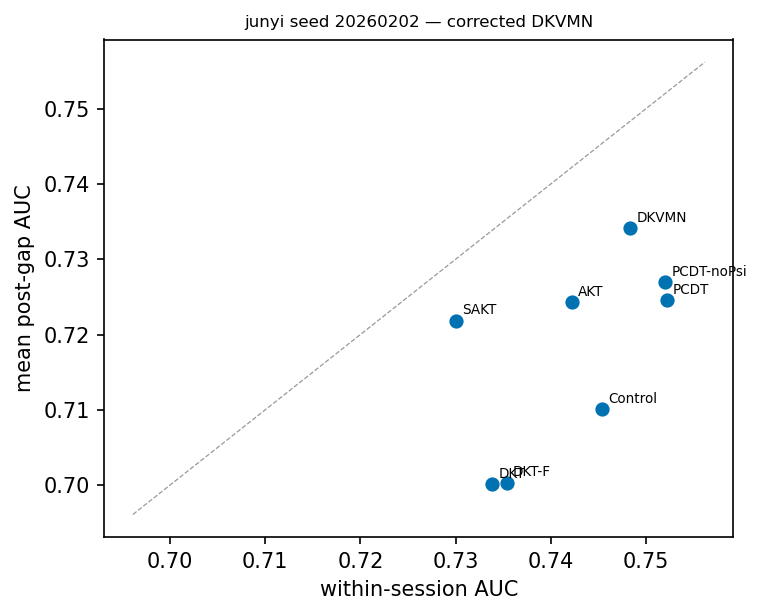

In [11]:
if RAISE_AFTER_SAVE:
    raise AssertionError(RAISE_AFTER_SAVE)

fig, ax = plt.subplots(figsize=(5.2, 4.2), dpi=150)
t = T9.dropna(subset=["auc_mean_postgap"])
ax.scatter(t["auc_within"], t["auc_mean_postgap"], s=34, c="#0072B2", zorder=3)
for r in t.itertuples():
    ax.annotate(r.model, (r.auc_within, r.auc_mean_postgap), fontsize=6.5,
                xytext=(3, 3), textcoords="offset points")
lim = [min(t.auc_within.min(), t.auc_mean_postgap.min()) - .004,
       max(t.auc_within.max(), t.auc_mean_postgap.max()) + .004]
ax.plot(lim, lim, lw=.6, ls="--", c="0.6")
ax.set_xlabel("within-session AUC"); ax.set_ylabel("mean post-gap AUC")
ax.set_title(f"{DATASET} seed {CFG.seed} — corrected DKVMN", fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(DIRS["fig"], "fig_within_vs_postgap_dkvmnfix.png"))
fig.savefig(os.path.join(DIRS["fig"], "fig_within_vs_postgap_dkvmnfix.pdf"))
plt.show()

In [12]:
CTX.finalize(status="complete",
             extra=dict(research_question="RQ2+RQ3 (DKVMN corrected)", dataset=DATASET,
                        seed=CFG.seed, source_run=SOURCE_RUN,
                        dkvmn_legacy_lag=False,
                        dkvmn_hidden=int(hh), dkvmn_params=int(npar), dkvmn_lr=best[1],
                        dkvmn_val_auc=float(best[0]),
                        dkvmn_auc_archived=float(_old["DKVMN"]),
                        dkvmn_auc_corrected=float(T2.loc[T2.model=="DKVMN","auc"].iloc[0]),
                        strongest_baseline=STRONGEST))


RUN DKVMNFIX__junyi__seed0 — complete
  runtime        129.46 min
  files written  19
  inputs read    4 (0 missing)
  concurrent     DKVMNFIX__junyi__seed1 (10 files), DKVMNFIX__junyi__seed2 (21 files), RQ4FIX__assistments_2021 (8 files), RQ4FIX__ednet_flat (8 files)
                 ran alongside this one and wrote only into its own folder — expected, not a problem
  isolation      OK — no finished run was modified
  manifest       /home/hamed/Downloads/Research/P02/PCDT_P2_runs/runs/DKVMNFIX__junyi__seed0/manifest.json


{'run_id': 'DKVMNFIX__junyi__seed0',
 'description': 'DKVMN refit with corrected memory ordering — junyi, seed 20260202',
 'status': 'complete',
 'notes': '',
 'fixture': False,
 'started': '2026-08-18 19:37:41',
 'finished': '2026-08-18 21:47:09',
 'runtime_minutes': 129.46,
 'output_dir': '/home/hamed/Downloads/Research/P02/PCDT_P2_runs/runs/DKVMNFIX__junyi__seed0',
 'environment': {'python': '3.13.9',
  'platform': 'Linux-7.0.0-28-generic-x86_64-with-glibc2.39',
  'numpy': '2.3.5',
  'pandas': '2.3.3',
  'torch': '2.12.0.dev20260408+cu128',
  'sklearn': '1.7.2',
  'scipy': '1.18.0',
  'matplotlib': '3.10.6',
  'cuda': True,
  'gpu': 'NVIDIA GeForce RTX 5080'},
 'config': None,
 'inputs': [{'label': 'RQ2RQ3__junyi__seed0/table1',
   'path': '/home/hamed/Downloads/Research/P02/PCDT_P2_runs/runs/RQ2RQ3__junyi__seed0/tables/table1_bucket_counts.csv',
   'present': True,
   'sha256': 'f0fc23903273c9fde1337084d9b29774e891205c71a4fcc391b187635468acce',
   'bytes': 137,
   'mtime': '2026-08